<a href="https://colab.research.google.com/github/ajaygiri7517/practicals/blob/main/Project_Edunet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [15]:
# 3. Load dataset
# Check if the file exists, if not, download it.
import os
if not os.path.exists('water_potability.csv'):
    print("water_potability.csv")
    # Verify download after attempting it
    if not os.path.exists('water_potability.csv'):
        raise FileNotFoundError("Failed to download 'water_potability.csv'. Please check the URL or network connection.")
else:
    print("water_potability.csv already exists.")

df = pd.read_csv("water_potability.csv")

print("Rows 20 through 30:")
print(df.iloc[1:10])


water_potability.csv already exists.
Rows 20 through 30:
          ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
1   3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2   8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3   8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4   9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   
5   5.584087  188.313324  28748.687739     7.544869  326.678363    280.467916   
6  10.223862  248.071735  28749.716544     7.513408  393.663396    283.651634   
7   8.635849  203.361523  13672.091764     4.563009  303.309771    474.607645   
8        NaN  118.988579  14285.583854     7.804174  268.646941    389.375566   
9  11.180284  227.231469  25484.508491     9.077200  404.041635    563.885481   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
1       15.180013        56.329076   4.500656           0  
2       16.8

In [17]:
# 4. Check missing values
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


In [18]:
# 5. Fill missing values with mean
df.fillna(df.mean(), inplace=True)


In [19]:
# 6. Split features & label
X = df.drop("Potability", axis=1)
y = df["Potability"]

In [20]:
# 7. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [21]:
# 8. Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
# Model 1: Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("\nLogistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))


Logistic Regression Accuracy: 0.6280487804878049


In [23]:
# Model 2: Random Forest (Better)
rf = RandomForestClassifier(n_estimators=200)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("\nRandom Forest Accuracy:",
      accuracy_score(y_test, rf_pred))


Random Forest Accuracy: 0.6798780487804879



Classification Report:

              precision    recall  f1-score   support

           0       0.69      0.88      0.78       412
           1       0.63      0.34      0.44       244

    accuracy                           0.68       656
   macro avg       0.66      0.61      0.61       656
weighted avg       0.67      0.68      0.65       656



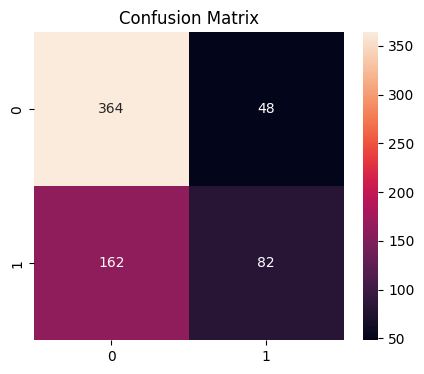

In [24]:
# Evaluation
print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()


In [25]:
# Manual Prediction
sample = X_test[0].reshape(1,-1)
result = rf.predict(sample)

if result[0] == 1:
    print("\nWater is SAFE to drink")
else:
    print("\nWater is NOT SAFE to drink")


Water is NOT SAFE to drink
